# Paper Figures

**Auto-load results from model configs!**

Scans `models/*/training_config.json` for results.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Publication style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR = Path("models")

print(f"Models dir: {MODELS_DIR.resolve()}")
print(f"Figures dir: {FIGURES_DIR.resolve()}")

Models dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/models
Figures dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures


In [33]:
# auto load results from model configs

# Mapping from folder name to display name and category
MODEL_MAPPING = {
    # Baseline
    "bert_9classes_final": ("Baseline", "baseline"),
    
    # In-processing methods (основные для paper)
    "bert_gdro_eta01_2ep": ("GroupDRO η=0.1", "in-processing"),
    "bert_gdro_eta03": ("GroupDRO η=0.3", "in-processing"),
    "bert_focal_loss": ("Focal Loss", "in-processing"),
    "bert_label_smoothing": ("Label Smoothing", "in-processing"),
    "bert_adversarial": ("Adversarial", "in-processing"),
    
    # Attribution-based methods
    "bert_scrubbing": ("Data Scrubbing", "attribution"),
    "bert_attr_reg": ("Attr Reg λ=0.1", "attribution"),
}

# Models to EXCLUDE from plots (old experiments, duplicates)
EXCLUDE_MODELS = {
    "bert_9classes_gdro_eta0.1_1ep",
    "bert_9classes_old_gdro_eta0.1_1ep", 
    "bert_9classes_old_rw_1ep",
    "bert_gdro_eta01_3ep",
    "bert_oversample_only",
    "bert_debiased_combo",
    "minilm_paraphrase_L3v2_lr_svm",
    "minilm_paraphrase_L3v2_lr_svm 1-34-46-181PM",
    "minilm_paraphrase_L3v2_lr_svm 1-53-12-267AM",
    "minilm_paraphrase_L3v2_lr_svm 1-54-22-135AM",
    "minilm_paraphrase_L3v2_lr_svm_old",
    "tfidf_logreg_binary_it",
}

def load_model_results(models_dir):
    """Load results from all model training_config.json files"""
    results = {}
    
    for model_dir in models_dir.iterdir():
        if not model_dir.is_dir():
            continue
        
        folder_name = model_dir.name
        
        # Skip excluded models
        if folder_name in EXCLUDE_MODELS:
            continue
            
        config_path = model_dir / "training_config.json"
        if not config_path.exists():
            print(f"  ⚠ No config: {folder_name}")
            continue
        
        with open(config_path) as f:
            config = json.load(f)
        
        if folder_name in MODEL_MAPPING:
            display_name, category = MODEL_MAPPING[folder_name]
        else:
            # Skip unmapped models
            print(f"  ⚠ Skipping unmapped: {folder_name}")
            continue
        
        # Extract metrics (handle different key names)
        results[display_name] = {
            "accuracy": config.get("accuracy") or config.get("test_accuracy"),
            "f1": config.get("macro_f1") or config.get("f1") or config.get("test_f1"),
            "tpr_worst": config.get("tpr_gap_worst_robust") or config.get("tpr_worst"),
            "tpr_macro": config.get("tpr_gap_macro_robust") or config.get("tpr_macro"),
            "category": category,
            "folder": folder_name
        }
        print(f"  ✓ Loaded: {display_name} ({folder_name})")
    
    return results

print("Loading model results...")
RESULTS = load_model_results(MODELS_DIR)
print(f"\nTotal: {len(RESULTS)} models")

Loading model results...
  ✓ Loaded: Label Smoothing (bert_label_smoothing)
  ⚠ No config: minilm_paraphrase_L3v2_lr_svm 1-34-46-181 PM
  ✓ Loaded: GroupDRO η=0.3 (bert_gdro_eta03)
  ✓ Loaded: Baseline (bert_9classes_final)
  ✓ Loaded: Data Scrubbing (bert_scrubbing)
  ✓ Loaded: Focal Loss (bert_focal_loss)
  ⚠ No config: minilm_paraphrase_L3v2_lr_svm 1-53-12-267 AM
  ⚠ No config: minilm_paraphrase_L3v2_lr_svm 1-54-22-135 AM
  ✓ Loaded: Attr Reg λ=0.1 (bert_attr_reg)
  ✓ Loaded: Adversarial (bert_adversarial)
  ✓ Loaded: GroupDRO η=0.1 (bert_gdro_eta01_2ep)

Total: 8 models


In [34]:
# Filter out incomplete results and show summary
RESULTS_COMPLETE = {k: v for k, v in RESULTS.items() 
                    if v["accuracy"] is not None and v["tpr_worst"] is not None}

print(f"Complete results: {len(RESULTS_COMPLETE)}/{len(RESULTS)}")
if len(RESULTS) != len(RESULTS_COMPLETE):
    missing = [k for k, v in RESULTS.items() if v["accuracy"] is None or v["tpr_worst"] is None]
    print(f"Missing metrics: {missing}")

# Show table
print("\n" + "="*80)
print(f"{'Model':<25} {'Acc':>8} {'F1':>8} {'Worst':>8} {'Macro':>8} {'Category':<15}")
print("-"*80)
for model, data in sorted(RESULTS_COMPLETE.items(), key=lambda x: -x[1].get('accuracy', 0)):
    print(f"{model:<25} {data['accuracy']:>8.3f} {data['f1']:>8.3f} "
          f"{data['tpr_worst']:>8.3f} {data['tpr_macro']:>8.3f} {data['category']:<15}")
print("="*80)

Complete results: 8/8

Model                          Acc       F1    Worst    Macro Category       
--------------------------------------------------------------------------------
Baseline                     0.609    0.621    0.329    0.116 baseline       
Label Smoothing              0.596    0.608    0.329    0.140 in-processing  
Data Scrubbing               0.594    0.611    0.300    0.112 attribution    
Focal Loss                   0.593    0.613    0.329    0.136 in-processing  
Attr Reg λ=0.1               0.583    0.601    0.335    0.116 attribution    
Adversarial                  0.574    0.594    0.429    0.132 in-processing  
GroupDRO η=0.3               0.552    0.572    0.282    0.135 in-processing  
GroupDRO η=0.1               0.548    0.553    0.265    0.113 in-processing  


In [35]:
# Prepare dataframe for plotting
df = pd.DataFrame(RESULTS_COMPLETE).T
df = df.reset_index().rename(columns={"index": "model"})

# Sort by category then accuracy
category_order = {"baseline": 0, "in-processing": 1, "attribution": 2, "other": 3}
df["cat_order"] = df["category"].map(category_order)
df = df.sort_values(["cat_order", "accuracy"], ascending=[True, False]).reset_index(drop=True)

# Colors
colors = {
    "baseline": "#2c3e50",
    "in-processing": "#3498db",
    "attribution": "#e74c3c",
    "other": "#95a5a6"
}
df["color"] = df["category"].map(colors)

print(f"Ready to plot {len(df)} models")
df[["model", "accuracy", "tpr_worst", "category"]]

Ready to plot 8 models


,model,accuracy,tpr_worst,category
0,Baseline,0.609,0.329,baseline
1,Label Smoothing,0.596189,0.329412,in-processing
2,Focal Loss,0.592559,0.329412,in-processing
3,Adversarial,0.57441,0.429412,in-processing
4,GroupDRO η=0.3,0.552269,0.282353,in-processing
5,GroupDRO η=0.1,0.547731,0.264706,in-processing
6,Data Scrubbing,0.594192,0.3,attribution
7,Attr Reg λ=0.1,0.583303,0.335294,attribution


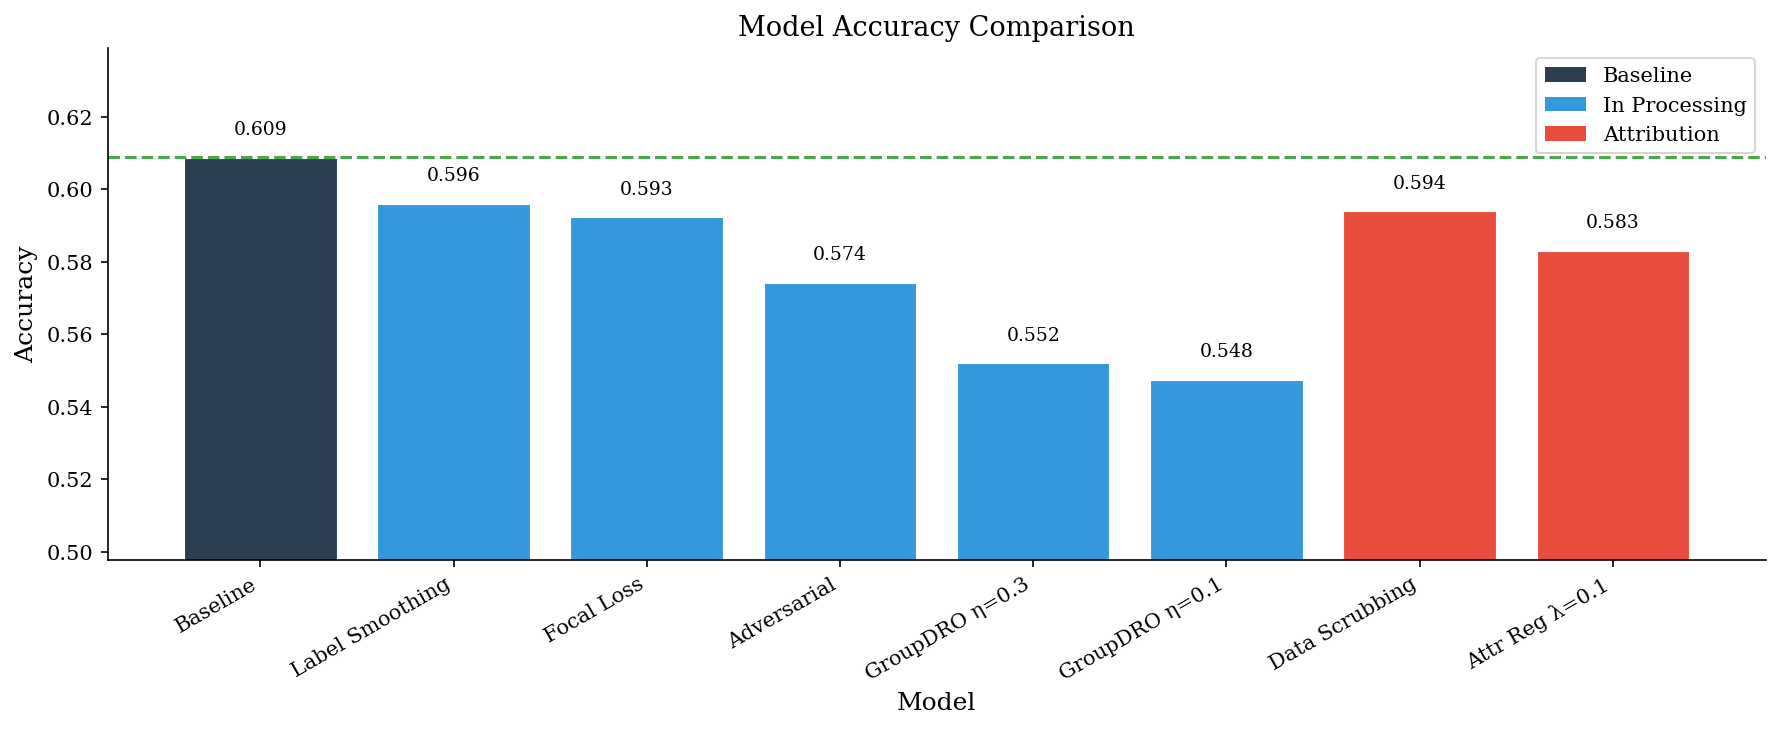

Saved: accuracy_comparison.pdf


In [36]:
# Figure 1: Accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df["model"], df["accuracy"], color=df["color"], edgecolor="white", linewidth=1.5)

# Baseline reference
if "Baseline" in RESULTS_COMPLETE:
    baseline_acc = RESULTS_COMPLETE["Baseline"]["accuracy"]
    ax.axhline(y=baseline_acc, color="green", linestyle="--", alpha=0.7, 
               label=f"Baseline ({baseline_acc:.3f})")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Model")
ax.set_title("Model Accuracy Comparison")
ax.set_ylim(min(df["accuracy"]) - 0.05, max(df["accuracy"]) + 0.03)
plt.xticks(rotation=30, ha="right")

# Value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat.replace("-", " ").title()) 
                   for cat, c in colors.items() if cat in df["category"].values]
ax.legend(handles=legend_elements, loc="upper right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_comparison.pdf")
plt.savefig(FIGURES_DIR / "accuracy_comparison.png")
plt.show()
print("Saved: accuracy_comparison.pdf")

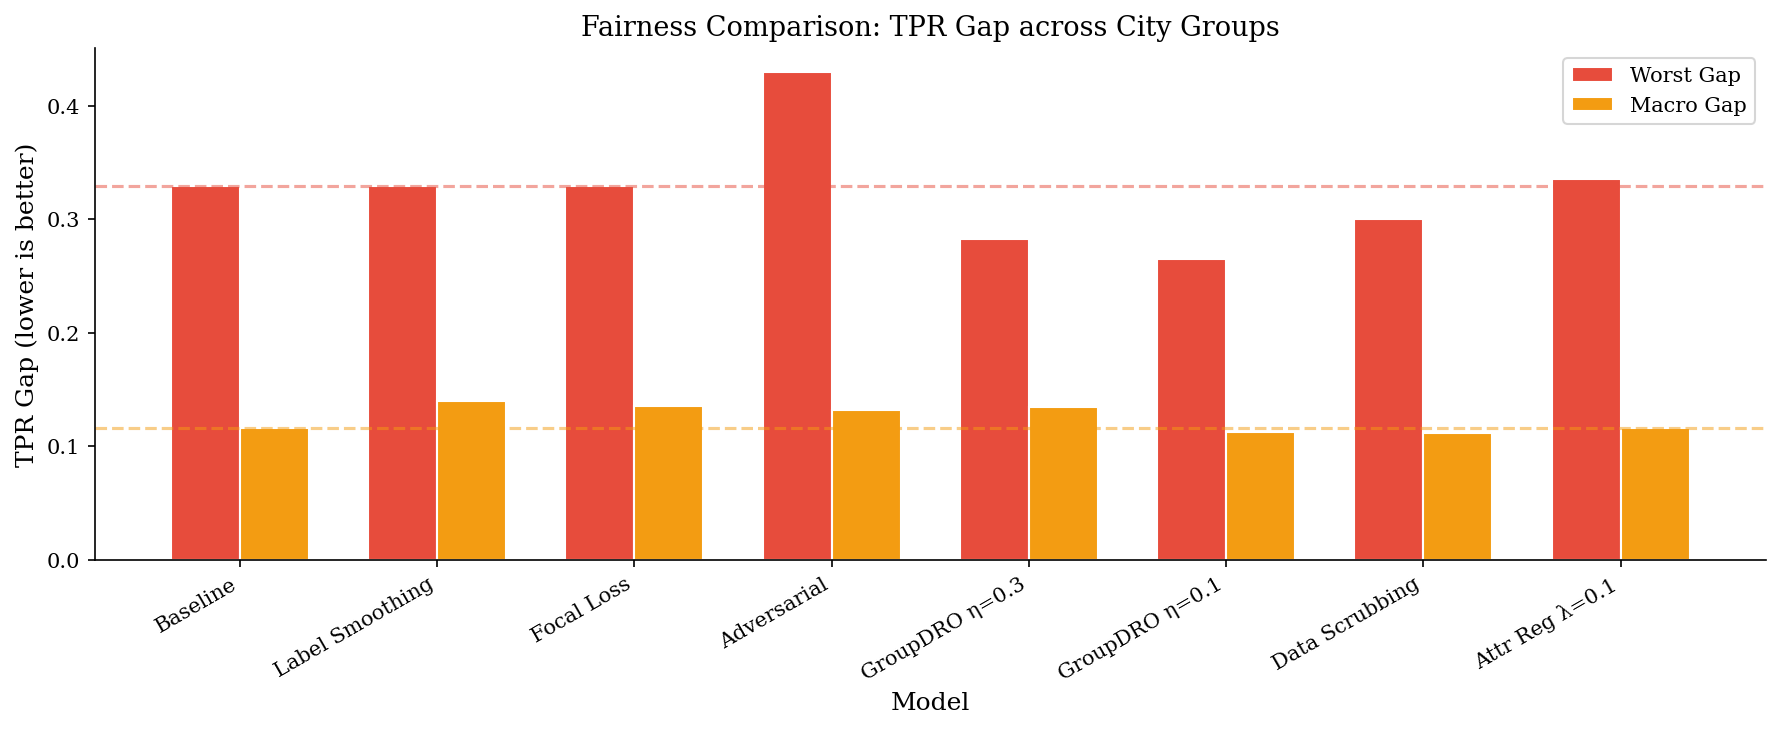

Saved: fairness_comparison.pdf


In [37]:
# Figure 2: Fairness comparison
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df))
width = 0.35

bars1 = ax.bar(x - width/2, df["tpr_worst"], width, label="Worst Gap", color="#e74c3c", edgecolor="white")
bars2 = ax.bar(x + width/2, df["tpr_macro"], width, label="Macro Gap", color="#f39c12", edgecolor="white")

# Baseline reference
if "Baseline" in RESULTS_COMPLETE:
    ax.axhline(y=RESULTS_COMPLETE["Baseline"]["tpr_worst"], color="#e74c3c", linestyle="--", alpha=0.5)
    ax.axhline(y=RESULTS_COMPLETE["Baseline"]["tpr_macro"], color="#f39c12", linestyle="--", alpha=0.5)

ax.set_ylabel("TPR Gap (lower is better)")
ax.set_xlabel("Model")
ax.set_title("Fairness Comparison: TPR Gap across City Groups")
ax.set_xticks(x)
ax.set_xticklabels(df["model"], rotation=30, ha="right")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fairness_comparison.pdf")
plt.savefig(FIGURES_DIR / "fairness_comparison.png")
plt.show()
print("Saved: fairness_comparison.pdf")

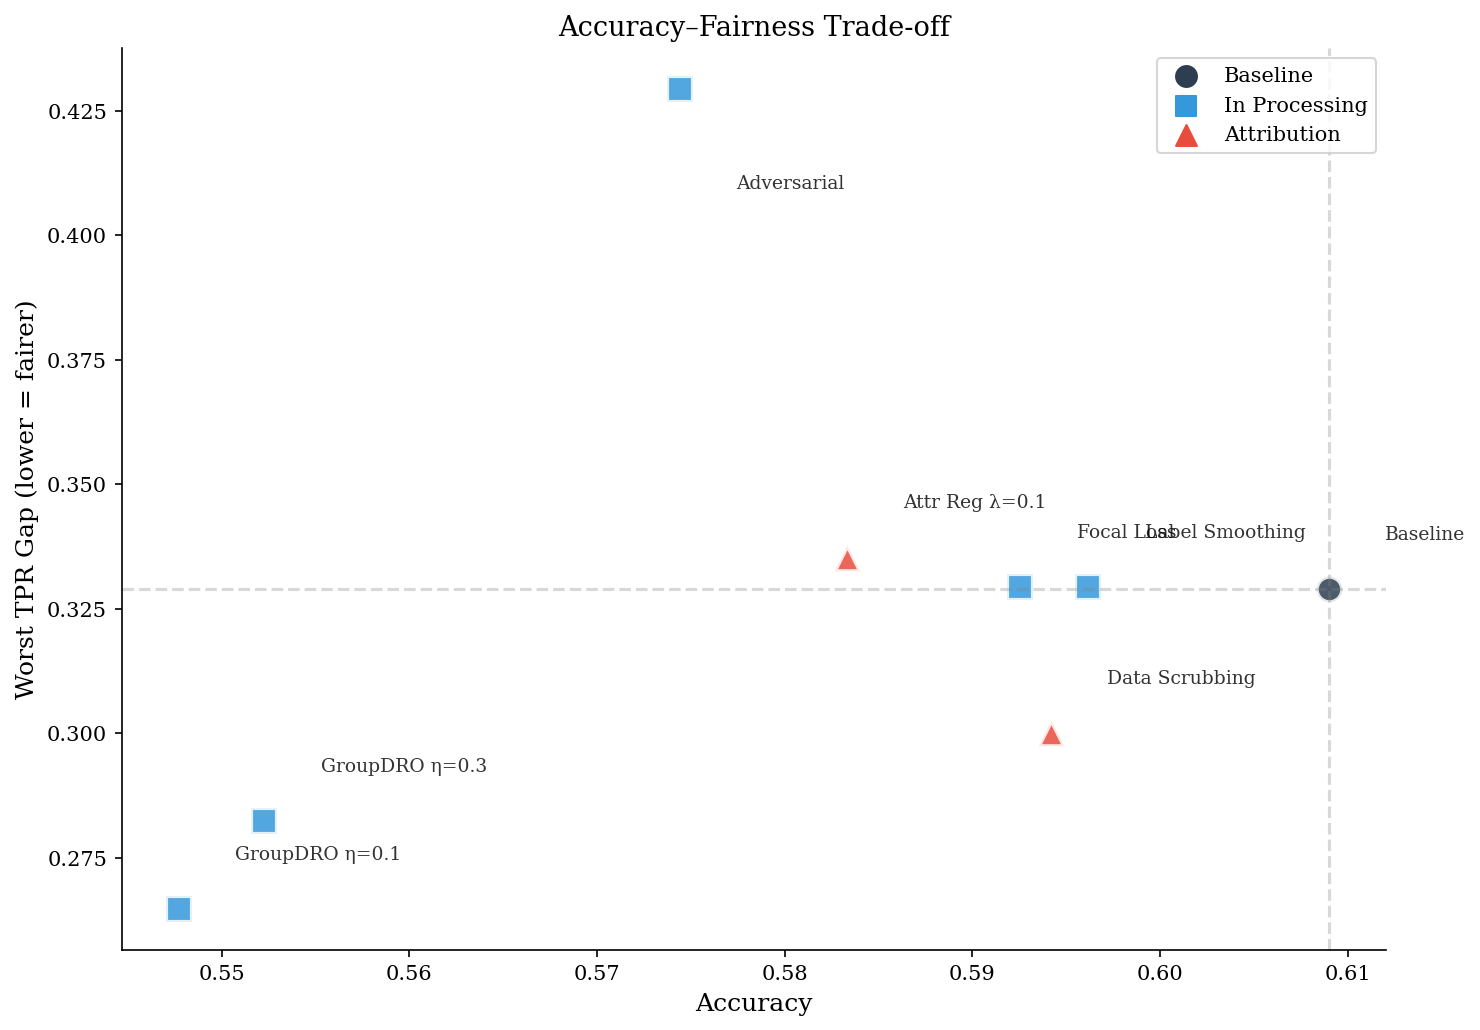

Saved: tradeoff_scatter.pdf


In [38]:
# Figure 3: Accuracy vs Fairness scatter (trade-off)
fig, ax = plt.subplots(figsize=(10, 7))

markers = {"baseline": "o", "in-processing": "s", "attribution": "^", "other": "d"}

for _, row in df.iterrows():
    ax.scatter(row["accuracy"], row["tpr_worst"], 
               c=row["color"], s=150, marker=markers.get(row["category"], "o"),
               edgecolors="white", linewidths=2, alpha=0.85)

# Annotate points
for _, row in df.iterrows():
    # Offset based on position to avoid overlap
    offset_x = 0.003
    offset_y = 0.01 if row["tpr_worst"] < 0.4 else -0.02
    ax.annotate(row["model"], (row["accuracy"] + offset_x, row["tpr_worst"] + offset_y), 
                fontsize=9, alpha=0.8)

# Reference lines from baseline
if "Baseline" in RESULTS_COMPLETE:
    ax.axhline(y=RESULTS_COMPLETE["Baseline"]["tpr_worst"], color="gray", linestyle="--", alpha=0.3)
    ax.axvline(x=RESULTS_COMPLETE["Baseline"]["accuracy"], color="gray", linestyle="--", alpha=0.3)

# Direction arrows
ax.annotate("← Better fairness", xy=(df["accuracy"].min(), df["tpr_worst"].min() - 0.02), 
            fontsize=10, color="green", alpha=0.7)
ax.annotate("Better accuracy →", xy=(df["accuracy"].max() - 0.02, df["tpr_worst"].max() + 0.01), 
            fontsize=10, color="green", alpha=0.7)

ax.set_xlabel("Accuracy")
ax.set_ylabel("Worst TPR Gap (lower = fairer)")
ax.set_title("Accuracy–Fairness Trade-off")

# Legend
legend_elements = [plt.scatter([], [], c=colors[cat], marker=markers[cat], s=100, label=cat.replace("-", " ").title())
                   for cat in ["baseline", "in-processing", "attribution"] if cat in df["category"].values]
ax.legend(handles=legend_elements, loc="upper right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tradeoff_scatter.pdf")
plt.savefig(FIGURES_DIR / "tradeoff_scatter.png")
plt.show()
print("Saved: tradeoff_scatter.pdf")

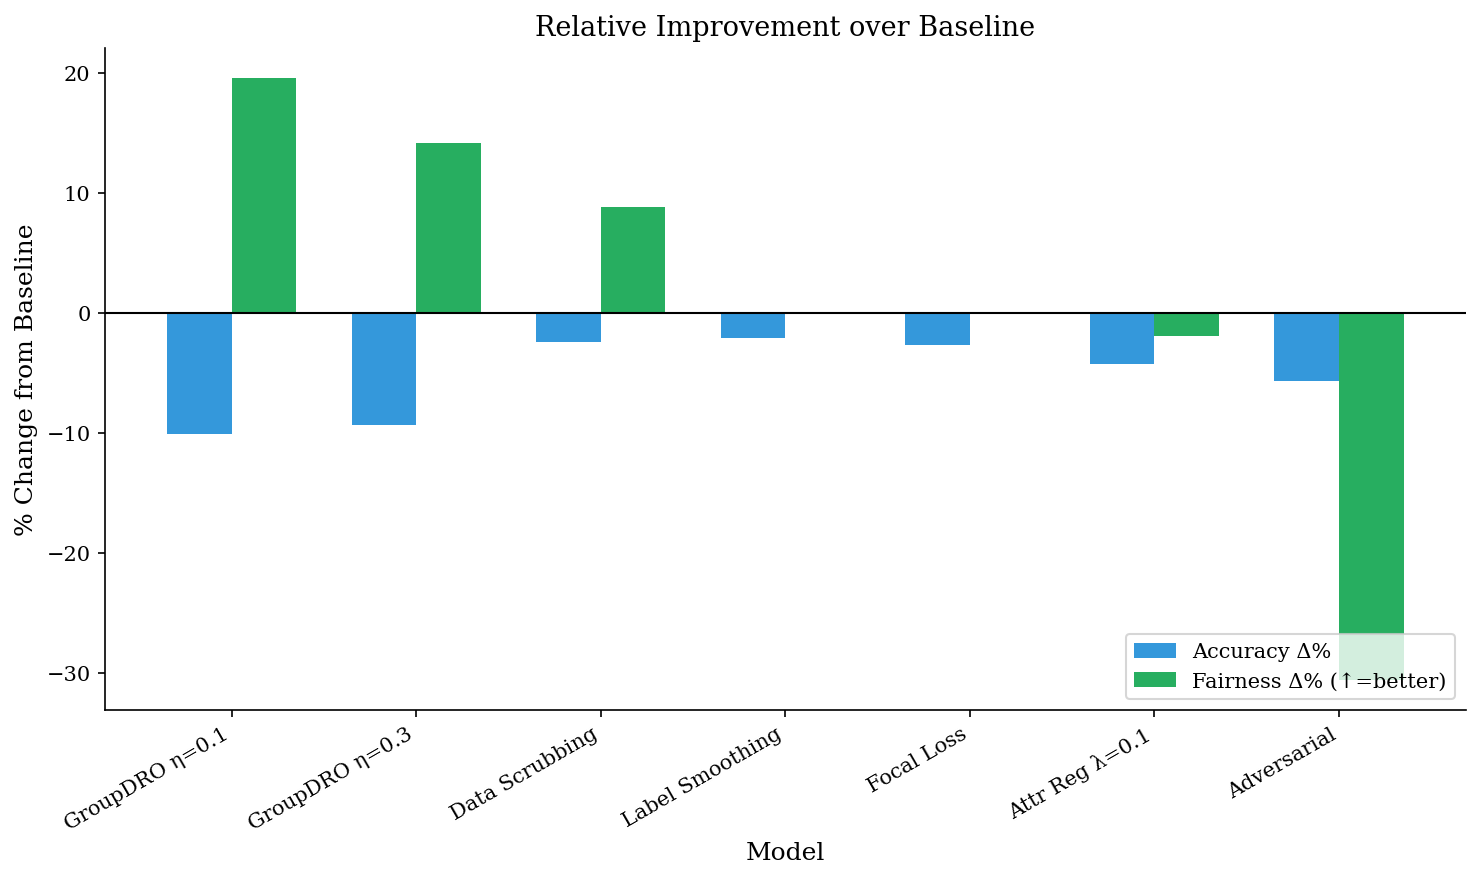

Saved: improvement_bars.pdf


In [39]:
# Figure 4: Relative improvement over baseline
if "Baseline" not in RESULTS_COMPLETE:
    print("No baseline found, skipping improvement chart")
else:
    baseline = RESULTS_COMPLETE["Baseline"]
    
    improvements = []
    for model, data in RESULTS_COMPLETE.items():
        if model == "Baseline":
            continue
        
        acc_change = (data["accuracy"] - baseline["accuracy"]) / baseline["accuracy"] * 100
        # Negative gap change = improvement
        fairness_change = -(data["tpr_worst"] - baseline["tpr_worst"]) / baseline["tpr_worst"] * 100
        
        improvements.append({
            "model": model,
            "acc_change": acc_change,
            "fairness_change": fairness_change,
            "category": data["category"]
        })
    
    df_imp = pd.DataFrame(improvements)
    df_imp = df_imp.sort_values("fairness_change", ascending=False).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(df_imp))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, df_imp["acc_change"], width, label="Accuracy Δ%", color="#3498db")
    bars2 = ax.bar(x + width/2, df_imp["fairness_change"], width, label="Fairness Δ% (↑=better)", color="#27ae60")
    
    ax.axhline(y=0, color="black", linewidth=1)
    ax.set_ylabel("% Change from Baseline")
    ax.set_xlabel("Model")
    ax.set_title("Relative Improvement over Baseline")
    ax.set_xticks(x)
    ax.set_xticklabels(df_imp["model"], rotation=30, ha="right")
    ax.legend(loc="lower right")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "improvement_bars.pdf")
    plt.savefig(FIGURES_DIR / "improvement_bars.png")
    plt.show()
    print("Saved: improvement_bars.pdf")

In [40]:
# Generate LaTeX table
print("\n" + "="*60)
print("LATEX TABLE (copy to paper)")
print("="*60)
print(r"\begin{tabular}{lcccc}")
print(r"\toprule")
print(r"\textbf{Model} & \textbf{Acc} & \textbf{F1} & \textbf{Worst Gap} & \textbf{Macro Gap} \\")
print(r"\midrule")

# Find best values
best_acc = max(v["accuracy"] for v in RESULTS_COMPLETE.values())
best_worst = min(v["tpr_worst"] for v in RESULTS_COMPLETE.values())
best_macro = min(v["tpr_macro"] for v in RESULTS_COMPLETE.values())

current_cat = None
for model in df["model"]:
    data = RESULTS_COMPLETE[model]
    
    # Category separator
    if data["category"] != current_cat:
        if current_cat is not None:
            print(r"\midrule")
        current_cat = data["category"]
    
    # Format with bold for best
    acc = f"\\textbf{{{data['accuracy']:.3f}}}" if data['accuracy'] == best_acc else f"{data['accuracy']:.3f}"
    f1 = f"{data['f1']:.3f}"
    worst = f"\\textbf{{{data['tpr_worst']:.3f}}}" if data['tpr_worst'] == best_worst else f"{data['tpr_worst']:.3f}"
    macro = f"\\textbf{{{data['tpr_macro']:.3f}}}" if data['tpr_macro'] == best_macro else f"{data['tpr_macro']:.3f}"
    
    # Mark adversarial as bad
    if data['tpr_worst'] > 0.4:
        worst = f"{data['tpr_worst']:.3f}$^\\dagger$"
    
    print(f"{model} & {acc} & {f1} & {worst} & {macro} \\\\")

print(r"\bottomrule")
print(r"\end{tabular}")
print("="*60)


LATEX TABLE (copy to paper)
\begin{tabular}{lcccc}
\toprule
\textbf{Model} & \textbf{Acc} & \textbf{F1} & \textbf{Worst Gap} & \textbf{Macro Gap} \\
\midrule
Baseline & \textbf{0.609} & 0.621 & 0.329 & 0.116 \\
\midrule
Label Smoothing & 0.596 & 0.608 & 0.329 & 0.140 \\
Focal Loss & 0.593 & 0.613 & 0.329 & 0.136 \\
Adversarial & 0.574 & 0.594 & 0.429$^\dagger$ & 0.132 \\
GroupDRO η=0.3 & 0.552 & 0.572 & 0.282 & 0.135 \\
GroupDRO η=0.1 & 0.548 & 0.553 & \textbf{0.265} & 0.113 \\
\midrule
Data Scrubbing & 0.594 & 0.611 & 0.300 & \textbf{0.112} \\
Attr Reg λ=0.1 & 0.583 & 0.601 & 0.335 & 0.116 \\
\bottomrule
\end{tabular}


In [41]:
# List generated figures
print("\nGENERATED FIGURES:")
for f in sorted(FIGURES_DIR.glob("*.pdf")):
    print(f"  {f.name}")
print(f"\nLocation: {FIGURES_DIR.resolve()}")


GENERATED FIGURES:
  accuracy_comparison.pdf
  fairness_comparison.pdf
  improvement_bars.pdf
  tradeoff_scatter.pdf

Location: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures
